### Process HRRRAK Grib Files: Large Juneau Domain

Notebook contents 
* Making a copy of other process script for the large juneau domain to process WY2024 and WY2025 

created by Cassie Lumbrazo\
last updated: Feb 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/large_juneau_domain'

### Open all the HRRR-AK Grib Files for a Water Year (WY) and Create a Simple NetCDF

To scale up the process for multiple HRRR .grib2 files across a folder structure, we need to:

* Walk through directories inside folderspath (`/hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2024`).
* Identify .grib2 files inside each date-named subfolder (`hrrr.20231001`, `hrrr.20231002`, etc.).
* Open and process all files for a given date just like in your original script.
* Merge all processed datasets and store them in a structured way.

* and deal with CRS issues


In [3]:
# adding this for parallel processing
from concurrent.futures import ProcessPoolExecutor

### Large Juneau Domain, f567, WY2025

In [39]:
import xarray as xr
import numpy as np
import pygrib
import os
from concurrent.futures import ProcessPoolExecutor
import rioxarray  # For CRS handling

# Define main folder path
folderspath = '/hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2025'

# List all date folders
date_folders = sorted([f for f in os.listdir(folderspath) if f.startswith("hrrr.")])

# List of desired variables (short names from GRIB output, keeping naming conventions)
desired_vars = [
    't',        # Temperature (surface level)
    'sp',       # Surface pressure
    '2t',       # 2 metre temperature
    '2r',       # 2 metre relative humidity
    'tp',       # Total Precipitation
    'prate',    # Precipitation rate
    '10u',      # 10 metre U wind component
    '10v',      # 10 metre V wind component
    'sdswrf',   # Surface downward short-wave radiation flux
    'sdlwrf',   # Surface downward long-wave radiation flux
    # Extras
    'gust',     # Wind speed (gust)
    'tcc',      # Total Cloud Cover
    'lcc',      # Low cloud cover
    'mcc',      # Medium cloud cover
    'hcc',      # High cloud cover
    'lai',      # Leaf Area Index
    '2d',       # 2 metre dewpoint temperature
    '2sh',      # 2 metre specific humidity
    'suswrf',   # Surface upward short-wave radiation flux
    'sulwrf',   # Surface upward long-wave radiation flux
    'orog',     # Orography
    'sdwe',     # Water equivalent of accumulated snow depth
    'sde',      # Snow depth
    'veg',      # Vegetation
    'vgtyp',    # Vegetation Type
    'gflux',    # Ground heat flux
]

def process_grib_file(grib_path):
    """ Process a single .grib2 file and return an xarray dataset """
    try:
        # Collect desired vars using pygrib
        grbs = pygrib.open(grib_path)
        var_info = {}
        
        for grb in grbs:
            short_name = grb.shortName.lower()
            if short_name in desired_vars:
                # Special filter: for 't', only keep surface level
                if short_name == 't' and not (grb.typeOfLevel == 'surface'):
                    continue
                key = f"{short_name}_{grb.level}_{grb.typeOfLevel}"
                var_info[key] = {
                    'short_name': short_name,
                    'level': grb.level,
                    'typeOfLevel': grb.typeOfLevel,
                    'data': grb.values,
                    'lat': grb.latlons()[0],
                    'lon': grb.latlons()[1],
                    'attrs': {  # Preserve GRIB metadata
                        'long_name': getattr(grb, 'name', short_name),
                        'units': getattr(grb, 'units', ''),
                        'GRIB_shortName': getattr(grb, 'shortName', short_name),
                        'GRIB_name': getattr(grb, 'name', ''),
                        'GRIB_cfName': getattr(grb, 'cfName', ''),
                        'GRIB_cfVarName': getattr(grb, 'cfVarName', ''),
                        'level': grb.level,
                        'typeOfLevel': grb.typeOfLevel
                    }
                }
        grbs.close()
        
        if not var_info:
            print(f"⚠️ Skipping {grib_path}: No desired variables found")
            return None
        
        # Create merged dataset
        datasets = []
        first_key = list(var_info.keys())[0]
        lat = var_info[first_key]['lat']
        lon = var_info[first_key]['lon']
        
        grouped_vars = {}
        for key, info in var_info.items():
            group_key = f"{info['short_name']}_{info['typeOfLevel']}"
            if group_key not in grouped_vars:
                grouped_vars[group_key] = []
            grouped_vars[group_key].append(info)
        
        for group_key, infos in grouped_vars.items():
            short_name = infos[0]['short_name']
            type_level = infos[0]['typeOfLevel']
            attrs = infos[0]['attrs']  # Use attrs from first (assuming consistent)
            
            if len(infos) == 1:
                info = infos[0]
                data = info['data']
                level = info['level']
                
                if type_level == 'surface' or (type_level == 'heightAboveGround' and level == 0):
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs=attrs,
                        name=short_name
                    )
                elif type_level == 'heightAboveGround' and level in [2, 10]:
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs={**attrs, 'heightAboveGround': level},  # Add height as attr
                        name=short_name
                    )
                else:
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs=attrs,
                        name=short_name
                    )
                datasets.append(da)
            else:
                # Multi-level (rare now)
                levels = [info['level'] for info in infos]
                data_stack = np.stack([info['data'] for info in infos], axis=0)
                da = xr.DataArray(
                    data_stack,
                    dims=['level', 'y', 'x'],
                    coords={
                        'level': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    attrs=attrs,
                    name=short_name
                )
                datasets.append(da)
        
        ds_merged = xr.merge(datasets, compat='override')
        
        # Calculate wind speed (from 10u and 10v), with attrs
        if '10u' in ds_merged and '10v' in ds_merged:
            ds_merged['wind'] = np.sqrt(ds_merged['10u']**2 + ds_merged['10v']**2)
            ds_merged['wind'].attrs.update({
                'long_name': '10 metre wind speed calculated from u and v wind components',
                'units': 'm s**-1',  # Assuming standard units
                'GRIB_shortName': '10m wind',
                'standard_name': 'wind speed',
                'GRIB_name': '10 metre wind speed',
                'GRIB_cfName': 'wind_speed',
                'GRIB_cfVarName': 'wind10'
            })
        
        # Rename variables (as in old code) - attrs should be preserved
        ds_merged = ds_merged.rename({
            't': 'temp_surface',
            'sp': 'pressure',
            '2t': 'temp',
            '2r': 'rh',
            'sdwe': 'swe',
            'sde': 'snowdepth',
            'sdswrf': 'swrad',
            'sdlwrf': 'lwrad',
            'tp': 'precip_total',
            'prate': 'precip_rate'
        })
        
        # Drop unnecessary variables if any
        drop_vars = [var for var in ['unknown'] if var in ds_merged]
        ds_merged = ds_merged.drop_vars(drop_vars, errors='ignore')
        
        # Extract time from filename
        import pandas as pd
        date_str = grib_path.split('/')[-2].split('.')[1]  # e.g., '20241001'
        hour_str = grib_path.split('/')[-1].split('.')[1]  # e.g., 't00z'
        hour = int(hour_str[1:3])  # e.g., 0
        time = pd.to_datetime(f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} {hour:02d}:00")
        ds_merged = ds_merged.assign_coords({'time': time})
        
        return ds_merged
    
    except Exception as e:
        print(f"⚠️ Error processing {grib_path}: {e}")
        return None

# Function to process a date folder in parallel
def process_date_folder(date_folder):
    date_path = os.path.join(folderspath, date_folder)
    grib_files = sorted([os.path.join(date_path, f) for f in os.listdir(date_path) if f.endswith(".grib2")])
    
    with ProcessPoolExecutor() as executor:
        ds_list = list(filter(None, executor.map(process_grib_file, grib_files)))
    
    if ds_list:
        try:
            return xr.concat(ds_list, dim="time")
        except ValueError as e:
            print(f"⚠️ Skipping {date_folder} due to concatenation error: {e}")
            return None
    return None

# Process all date folders in parallel
with ProcessPoolExecutor() as executor:
    all_ds_list = list(filter(None, executor.map(process_date_folder, date_folders)))

# Merge all datasets across all days
if all_ds_list:
    final_ds = xr.concat(all_ds_list, dim="time")
    print("✅ Successfully merged all datasets!")
    
    # --- Save raw NetCDF before CRS processing ---
    raw_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_raw.nc"
    final_ds.to_netcdf(raw_output_path)
    print(f"📁 Saved raw dataset to {raw_output_path}")
    
    # --- CRS Check and Reprojection ---
    print(f"Original CRS: {final_ds.rio.crs}")
    
    # Assign CRS if not set (assuming WGS84 lat/lon)
    final_ds.rio.write_crs("EPSG:4326", inplace=True)
    print("Assigned CRS: EPSG:4326")
    
    # Drop old integer x/y coords to avoid rename conflict
    final_ds = final_ds.drop_vars(['x', 'y'], errors='ignore')
    
    # Rename dimensions and set spatial dims
    final_ds = final_ds.rename({'longitude': 'x', 'latitude': 'y'})
    final_ds = final_ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    
    # Extract 1D x and y coordinates from the 2D grid
    x_1d = final_ds['x'].isel(y=0)  # same x values across rows
    y_1d = final_ds['y'].isel(x=0)  # same y values down columns
    
    # Assign 1D coords
    final_ds = final_ds.assign_coords(x=x_1d, y=y_1d)
    
    # Drop old 2D coords
    final_ds = final_ds.drop_vars(['x', 'y'])
    final_ds = final_ds.set_coords([])
    final_ds = final_ds.assign_coords({'x': x_1d, 'y': y_1d})
    
    # Reproject to UTM
    ds_utm = final_ds.rio.reproject("EPSG:32608")
    print("Reprojected to UTM (EPSG:32608)")
    
    # Save the reprojected dataset
    utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc"
    ds_utm.to_netcdf(utm_output_path)
    print(f"📁 Saved reprojected dataset to {utm_output_path}")
else:
    print("⚠️ No valid datasets found.")

✅ Successfully merged all datasets!
📁 Saved raw dataset to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_raw.nc
Original CRS: None
Assigned CRS: EPSG:4326
Reprojected to UTM (EPSG:32608)
📁 Saved reprojected dataset to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc


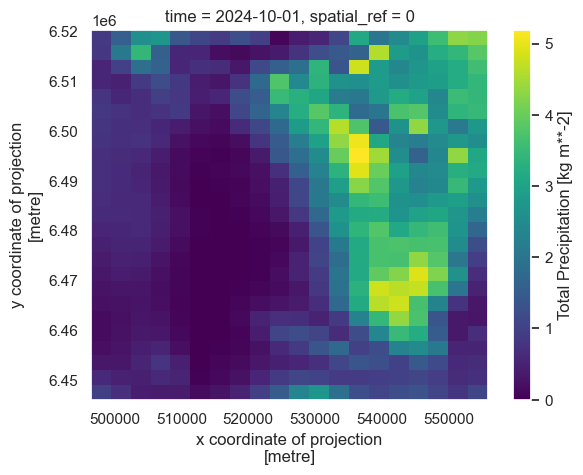

In [45]:
ds_utm['precip_total'][0].plot()

Did not run this yet....

### Large Juneau Domain, f567, WY2024

In [ ]:
# Define main folder path
folderspath = '/hdd/snow_hydrology/hrrrak/large_juneau_domain/f567/WY2024'

# List all date folders
date_folders = sorted([f for f in os.listdir(folderspath) if f.startswith("hrrr.")])

# List of desired variables (short names from GRIB output, keeping naming conventions)
desired_vars = [
    't',        # Temperature (surface level)
    'sp',       # Surface pressure
    '2t',       # 2 metre temperature
    '2r',       # 2 metre relative humidity
    'tp',       # Total Precipitation
    'prate',    # Precipitation rate
    '10u',      # 10 metre U wind component
    '10v',      # 10 metre V wind component
    'sdswrf',   # Surface downward short-wave radiation flux
    'sdlwrf',   # Surface downward long-wave radiation flux
    # Extras
    'gust',     # Wind speed (gust)
    'tcc',      # Total Cloud Cover
    'lcc',      # Low cloud cover
    'mcc',      # Medium cloud cover
    'hcc',      # High cloud cover
    'lai',      # Leaf Area Index
    '2d',       # 2 metre dewpoint temperature
    '2sh',      # 2 metre specific humidity
    'suswrf',   # Surface upward short-wave radiation flux
    'sulwrf',   # Surface upward long-wave radiation flux
    'orog',     # Orography
    'sdwe',     # Water equivalent of accumulated snow depth
    'sde',      # Snow depth
    'veg',      # Vegetation
    'vgtyp',    # Vegetation Type
    'gflux',    # Ground heat flux
]

def process_grib_file(grib_path):
    """ Process a single .grib2 file and return an xarray dataset """
    try:
        # Collect desired vars using pygrib
        grbs = pygrib.open(grib_path)
        var_info = {}
        
        for grb in grbs:
            short_name = grb.shortName.lower()
            if short_name in desired_vars:
                # Special filter: for 't', only keep surface level
                if short_name == 't' and not (grb.typeOfLevel == 'surface'):
                    continue
                key = f"{short_name}_{grb.level}_{grb.typeOfLevel}"
                var_info[key] = {
                    'short_name': short_name,
                    'level': grb.level,
                    'typeOfLevel': grb.typeOfLevel,
                    'data': grb.values,
                    'lat': grb.latlons()[0],
                    'lon': grb.latlons()[1],
                    'attrs': {  # Preserve GRIB metadata
                        'long_name': getattr(grb, 'name', short_name),
                        'units': getattr(grb, 'units', ''),
                        'GRIB_shortName': getattr(grb, 'shortName', short_name),
                        'GRIB_name': getattr(grb, 'name', ''),
                        'GRIB_cfName': getattr(grb, 'cfName', ''),
                        'GRIB_cfVarName': getattr(grb, 'cfVarName', ''),
                        'level': grb.level,
                        'typeOfLevel': grb.typeOfLevel
                    }
                }
        grbs.close()
        
        if not var_info:
            print(f"⚠️ Skipping {grib_path}: No desired variables found")
            return None
        
        # Create merged dataset
        datasets = []
        first_key = list(var_info.keys())[0]
        lat = var_info[first_key]['lat']
        lon = var_info[first_key]['lon']
        
        grouped_vars = {}
        for key, info in var_info.items():
            group_key = f"{info['short_name']}_{info['typeOfLevel']}"
            if group_key not in grouped_vars:
                grouped_vars[group_key] = []
            grouped_vars[group_key].append(info)
        
        for group_key, infos in grouped_vars.items():
            short_name = infos[0]['short_name']
            type_level = infos[0]['typeOfLevel']
            attrs = infos[0]['attrs']  # Use attrs from first (assuming consistent)
            
            if len(infos) == 1:
                info = infos[0]
                data = info['data']
                level = info['level']
                
                if type_level == 'surface' or (type_level == 'heightAboveGround' and level == 0):
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs=attrs,
                        name=short_name
                    )
                elif type_level == 'heightAboveGround' and level in [2, 10]:
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs={**attrs, 'heightAboveGround': level},  # Add height as attr
                        name=short_name
                    )
                else:
                    da = xr.DataArray(
                        data,
                        dims=['y', 'x'],
                        coords={
                            'y': range(data.shape[0]),
                            'x': range(data.shape[1]),
                            'latitude': (['y', 'x'], lat),
                            'longitude': (['y', 'x'], lon)
                        },
                        attrs=attrs,
                        name=short_name
                    )
                datasets.append(da)
            else:
                # Multi-level (rare now)
                levels = [info['level'] for info in infos]
                data_stack = np.stack([info['data'] for info in infos], axis=0)
                da = xr.DataArray(
                    data_stack,
                    dims=['level', 'y', 'x'],
                    coords={
                        'level': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon)
                    },
                    attrs=attrs,
                    name=short_name
                )
                datasets.append(da)
        
        ds_merged = xr.merge(datasets, compat='override')
        
        # Calculate wind speed (from 10u and 10v), with attrs
        if '10u' in ds_merged and '10v' in ds_merged:
            ds_merged['wind'] = np.sqrt(ds_merged['10u']**2 + ds_merged['10v']**2)
            ds_merged['wind'].attrs.update({
                'long_name': '10 metre wind speed calculated from u and v wind components',
                'units': 'm s**-1',  # Assuming standard units
                'GRIB_shortName': '10m wind',
                'standard_name': 'wind speed',
                'GRIB_name': '10 metre wind speed',
                'GRIB_cfName': 'wind_speed',
                'GRIB_cfVarName': 'wind10'
            })
        
        # Rename variables (as in old code) - attrs should be preserved
        ds_merged = ds_merged.rename({
            't': 'temp_surface',
            'sp': 'pressure',
            '2t': 'temp',
            '2r': 'rh',
            'sdwe': 'swe',
            'sde': 'snowdepth',
            'sdswrf': 'swrad',
            'sdlwrf': 'lwrad',
            'tp': 'precip_total',
            'prate': 'precip_rate'
        })
        
        # Drop unnecessary variables if any
        drop_vars = [var for var in ['unknown'] if var in ds_merged]
        ds_merged = ds_merged.drop_vars(drop_vars, errors='ignore')
        
        # Extract time from filename
        import pandas as pd
        date_str = grib_path.split('/')[-2].split('.')[1]  # e.g., '20241001'
        hour_str = grib_path.split('/')[-1].split('.')[1]  # e.g., 't00z'
        hour = int(hour_str[1:3])  # e.g., 0
        time = pd.to_datetime(f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:]} {hour:02d}:00")
        ds_merged = ds_merged.assign_coords({'time': time})
        
        return ds_merged
    
    except Exception as e:
        print(f"⚠️ Error processing {grib_path}: {e}")
        return None

# Function to process a date folder in parallel
def process_date_folder(date_folder):
    date_path = os.path.join(folderspath, date_folder)
    grib_files = sorted([os.path.join(date_path, f) for f in os.listdir(date_path) if f.endswith(".grib2")])
    
    with ProcessPoolExecutor() as executor:
        ds_list = list(filter(None, executor.map(process_grib_file, grib_files)))
    
    if ds_list:
        try:
            return xr.concat(ds_list, dim="time")
        except ValueError as e:
            print(f"⚠️ Skipping {date_folder} due to concatenation error: {e}")
            return None
    return None

# Process all date folders in parallel
with ProcessPoolExecutor() as executor:
    all_ds_list = list(filter(None, executor.map(process_date_folder, date_folders)))

# Merge all datasets across all days
if all_ds_list:
    final_ds = xr.concat(all_ds_list, dim="time")
    print("✅ Successfully merged all datasets!")
    
    # --- Save raw NetCDF before CRS processing ---
    raw_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2024_raw.nc"
    final_ds.to_netcdf(raw_output_path)
    print(f"📁 Saved raw dataset to {raw_output_path}")
    
    # --- CRS Check and Reprojection ---
    print(f"Original CRS: {final_ds.rio.crs}")
    
    # Assign CRS if not set (assuming WGS84 lat/lon)
    final_ds.rio.write_crs("EPSG:4326", inplace=True)
    print("Assigned CRS: EPSG:4326")
    
    # Drop old integer x/y coords to avoid rename conflict
    final_ds = final_ds.drop_vars(['x', 'y'], errors='ignore')
    
    # Rename dimensions and set spatial dims
    final_ds = final_ds.rename({'longitude': 'x', 'latitude': 'y'})
    final_ds = final_ds.rio.set_spatial_dims(x_dim='x', y_dim='y')
    
    # Extract 1D x and y coordinates from the 2D grid
    x_1d = final_ds['x'].isel(y=0)  # same x values across rows
    y_1d = final_ds['y'].isel(x=0)  # same y values down columns
    
    # Assign 1D coords
    final_ds = final_ds.assign_coords(x=x_1d, y=y_1d)
    
    # Drop old 2D coords
    final_ds = final_ds.drop_vars(['x', 'y'])
    final_ds = final_ds.set_coords([])
    final_ds = final_ds.assign_coords({'x': x_1d, 'y': y_1d})
    
    # Reproject to UTM
    ds_utm = final_ds.rio.reproject("EPSG:32608")
    print("Reprojected to UTM (EPSG:32608)")
    
    # Save the reprojected dataset
    utm_output_path = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2024_utm.nc"
    ds_utm.to_netcdf(utm_output_path)
    print(f"📁 Saved reprojected dataset to {utm_output_path}")
else:
    print("⚠️ No valid datasets found.")

✅ Successfully merged all datasets!
📁 Saved raw dataset to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_raw.nc
Original CRS: None
Assigned CRS: EPSG:4326
Reprojected to UTM (EPSG:32608)
📁 Saved reprojected dataset to /hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_merged_grib_f567_WY2025_utm.nc
